# Übungsblatt 2: Projektive Entzerrung
**Computer Vision – Tempelhof Schrägbild-Entzerrung**

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io

img = io.imread('schraegbild_tempelhof.jpg')
print(f'Bildgröße: {img.shape[1]} × {img.shape[0]} Pixel, {img.shape[2]} Kanäle')

Bildgröße: 1000 × 757 Pixel, 3 Kanäle


## Aufgabe a: Passpunkte messen und visualisieren

Als Passpunkte werden die vier Ecken des Flugfeldes (Rasenfläche) gewählt.
Diese bilden in der Realität ein annähernd rechteckiges Gebiet.

- **b_i** (rot): gemessene Bildkoordinaten im Schrägbild `(x=Spalte, y=Zeile)`
- **o_i** (blau): Wunschkoordinaten im Zielbild (Ecken des Ausgabebildes)

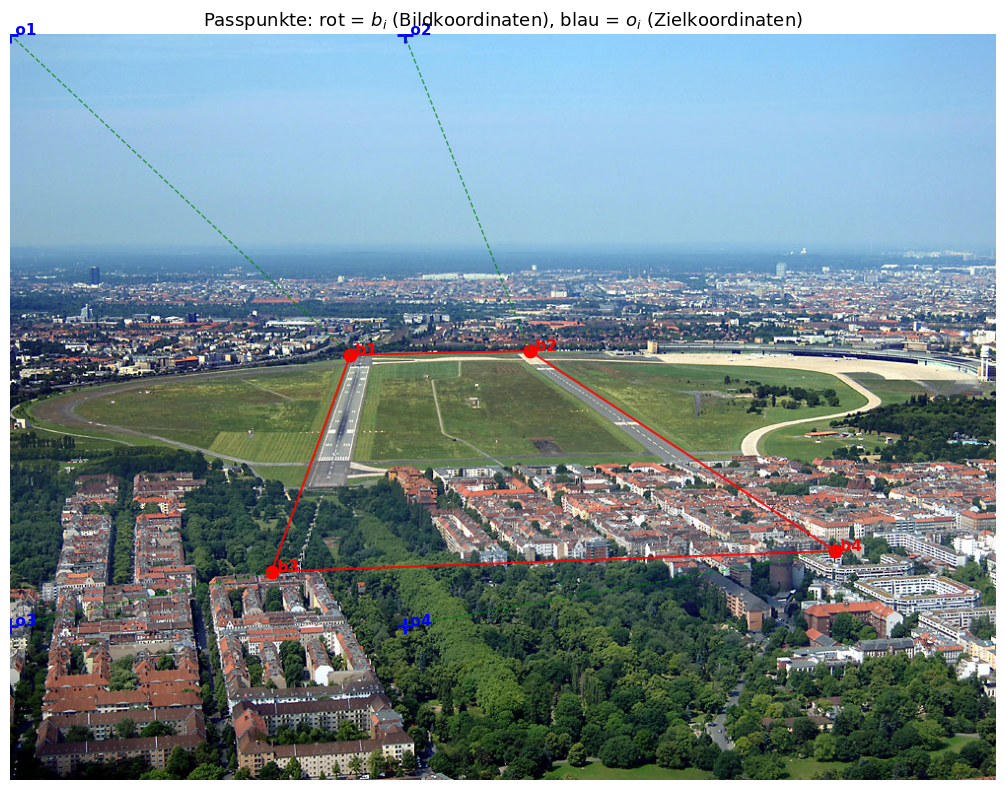

b_i (Bildkoordinaten):
  b1 = (345, 325)
  b2 = (527, 321)
  b3 = (265, 545)
  b4 = (837, 524)

o_i (Zielkoordinaten, Ausgabebild 400×600):
  o1 = (0, 0)
  o2 = (400, 0)
  o3 = (0, 600)
  o4 = (400, 600)


In [56]:
# Passpunkte b_i im Schrägbild (x=Spalte, y=Zeile), visuell ausgemessen
b = np.array([
    [345, 325],   # b1: oben-links  (NW-Ecke des Flugfeldes)
    [527, 321],   # b2: oben-rechts (NO-Ecke, nahe Ovalstrecke)
    [265, 545],   # b3: unten-links  (SW-Ecke)
    [837, 524],   # b4: unten-rechts (SO-Ecke)
], dtype=float)

# Zielkoordinaten o_i: Ecken des Ausgabebildes
W_out, H_out = 400, 600
o = np.array([
    [0,     0    ],   # o1: oben-links
    [W_out, 0    ],   # o2: oben-rechts
    [0,     H_out],   # o3: unten-links
    [W_out, H_out],   # o4: unten-rechts
], dtype=float)

# Visualisierung
fig, ax = plt.subplots(figsize=(13, 8))
ax.imshow(img)

# b_i Viereck (rot)
quad_order = [0, 1, 3, 2, 0]  # TL → TR → BR → BL → TL
bq = b[quad_order]
ax.plot(bq[:, 0], bq[:, 1], 'r-', linewidth=1.5, alpha=0.85)

# o_i – in Bildkoordinaten des Quellbildes anzeigen (Ecken des Ausgabebildes)
# o_i liegen in Ausgabekoordinaten; hier zur Veranschaulichung direkt eingetragen
for i, (bx, by) in enumerate(b):
    ax.plot(bx, by, 'ro', markersize=9)
    ax.annotate(f' b{i+1}', (bx, by), color='red', fontsize=11, fontweight='bold')

for i, (ox, oy) in enumerate(o):
    ax.plot(ox, oy, 'b+', markersize=12, markeredgewidth=2)
    ax.annotate(f' o{i+1}', (ox, oy), color='blue', fontsize=11, fontweight='bold')

# Verbindungslinien b_i → o_i
for (bx, by), (ox, oy) in zip(b, o):
    ax.plot([bx, ox], [by, oy], 'g--', linewidth=1, alpha=0.7)

ax.set_title('Passpunkte: rot = $b_i$ (Bildkoordinaten), blau = $o_i$ (Zielkoordinaten)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

print('b_i (Bildkoordinaten):')
for i, (bx, by) in enumerate(b):
    print(f'  b{i+1} = ({bx:.0f}, {by:.0f})')
print(f'\no_i (Zielkoordinaten, Ausgabebild {W_out}×{H_out}):')
for i, (ox, oy) in enumerate(o):
    print(f'  o{i+1} = ({ox:.0f}, {oy:.0f})')

## Aufgabe b: Projektive Transformation berechnen

Die projektive Transformation (Homographie) $H$ bildet Quellpunkte $b_i$ auf Zielpunkte $o_i$ ab:

$$u = \frac{a_1 x + a_2 y + a_3}{c_1 x + c_2 y + 1}, \quad
  v = \frac{b_1 x + b_2 y + b_3}{c_1 x + c_2 y + 1}$$

Mit $(x,y) = b_i$ und $(u,v) = o_i$ ergibt sich für jeden Passpunkt ein lineares Gleichungssystem:

$$a_1 x + a_2 y + a_3 - c_1\, u\, x - c_2\, u\, y = u$$
$$b_1 x + b_2 y + b_3 - c_1\, v\, x - c_2\, v\, y = v$$

Vier Passpunkte liefern 8 Gleichungen für die 8 Unbekannten $[a_1, a_2, a_3, b_1, b_2, b_3, c_1, c_2]$.

In [57]:
def compute_homography(b_pts, o_pts):
    """Berechnet die 8 Homographie-Parameter aus 4 Passpunkt-Paaren.
    Vorwärtstransformation H:  b_i  -->  o_i
    Rückgabe: [a1, a2, a3, b1, b2, b3, c1, c2]
    """
    M = []
    rhs = []
    for (bx, by), (ox, oy) in zip(b_pts, o_pts):
        M.append([bx, by, 1,  0,  0,  0, -ox*bx, -ox*by])
        rhs.append(ox)
        M.append([ 0,  0, 0, bx, by,  1, -oy*bx, -oy*by])
        rhs.append(oy)
    return np.linalg.solve(np.array(M), np.array(rhs))

params = compute_homography(b, o)
a1, a2, a3, h1, h2, h3, c1, c2 = params  # h1..h3 statt b1..b3 (Namenskollision mit Passpunkten)

print('Homographie-Parameter:')
names = ['a1', 'a2', 'a3', 'b1', 'b2', 'b3', 'c1', 'c2']
for name, val in zip(names, params):
    print(f'  {name} = {val:.6f}')

Homographie-Parameter:
  a1 = -0.935855
  a2 = -0.340311
  a3 = 433.471011
  b1 = -0.082988
  b2 = -3.775948
  b3 = 1255.814065
  c1 = -0.000066
  c2 = -0.004323


In [58]:
# Verifikation: H^{-1}(o_i) sollte b_i ergeben
def H_inv(x, y, p):
    """Inverse Projektivtransformation (Vorlesungsformel): (x,y) im Zielbild → (x',y') im Quellbild."""
    a1, a2, a3, b1, b2, b3, c1, c2 = p
    denom = (b1*c2 - b2*c1)*x + (a2*c1 - a1*c2)*y + (a1*b2 - a2*b1)
    x_src = ((b2 - c2*b3)*x + (a3*c2 - a2)*y + a2*b3 - a3*b2) / denom
    y_src = ((b3*c1 - b1)*x + (a1 - a3*c1)*y + a3*b1 - a1*b3) / denom
    return x_src, y_src

print('Verifikation: H⁻¹(o_i) → b\'_i   (sollte ≈ b_i sein)')
print(f'{"":<5} {"H⁻¹(o_i)":<22} {"b_i (gemessen)":<22} {"Abstand"}')
for i, (ox, oy) in enumerate(o):
    xp, yp = H_inv(ox, oy, params)
    dist = np.hypot(xp - b[i, 0], yp - b[i, 1])
    print(f'  b{i+1}:  ({xp:7.2f}, {yp:7.2f})   ({b[i,0]:5.0f}, {b[i,1]:5.0f})          {dist:.2e}')

Verifikation: H⁻¹(o_i) → b'_i   (sollte ≈ b_i sein)
      H⁻¹(o_i)               b_i (gemessen)         Abstand
  b1:  ( 345.00,  325.00)   (  345,   325)          1.27e-13
  b2:  ( 527.00,  321.00)   (  527,   321)          1.27e-13
  b3:  ( 265.00,  545.00)   (  265,   545)          2.54e-13
  b4:  ( 837.00,  524.00)   (  837,   524)          8.66e-13


## Aufgabe c: Projektive Warp-Funktion

Indirekte Umbildung (Backward Warping): Für jeden Ausgabepixel $(x, y)$ wird der
zugehörige Quellpixel $(x', y')$ über die inverse Formel aus der Vorlesung berechnet:

$$x' = \frac{(b_2 - c_2 b_3)\,x + (a_3 c_2 - a_2)\,y + a_2 b_3 - a_3 b_2}
            {(b_1 c_2 - b_2 c_1)\,x + (a_2 c_1 - a_1 c_2)\,y + a_1 b_2 - a_2 b_1}$$

$$y' = \frac{(b_3 c_1 - b_1)\,x + (a_1 - a_3 c_1)\,y + a_3 b_1 - a_1 b_3}
            {(b_1 c_2 - b_2 c_1)\,x + (a_2 c_1 - a_1 c_2)\,y + a_1 b_2 - a_2 b_1}$$

In [59]:
def projective_warp(img, params, H_out, W_out):
    """Projektive Bildtransformation mittels indirekter Umbildung (Nearest-Neighbor).
    
    params: [a1, a2, a3, b1, b2, b3, c1, c2] der Vorwärts-Homographie H: Quelle → Ziel.
    Die inverse Formel aus der Vorlesung mappt Zielkoordinaten zurück ins Quellbild.
    """
    a1, a2, a3, b1, b2, b3, c1, c2 = params

    # Alle Ausgabepixelkoordinaten auf einmal (vektorisiert)
    y_out, x_out = np.mgrid[0:H_out, 0:W_out]
    x = x_out.astype(float)
    y = y_out.astype(float)

    # Gemeinsamer Nenner
    denom = (b1*c2 - b2*c1)*x + (a2*c1 - a1*c2)*y + (a1*b2 - a2*b1)

    # Quellkoordinaten nach inverser Projektivformel (Vorlesung)
    x_src = ((b2 - c2*b3)*x + (a3*c2 - a2)*y + a2*b3 - a3*b2) / denom
    y_src = ((b3*c1 - b1)*x + (a1 - a3*c1)*y + a3*b1 - a1*b3) / denom

    # Nearest-Neighbor-Sampling
    H_in, W_in = img.shape[:2]
    xi = np.round(x_src).astype(int)
    yi = np.round(y_src).astype(int)
    valid = (xi >= 0) & (xi < W_in) & (yi >= 0) & (yi < H_in)

    output = np.zeros((H_out, W_out) + img.shape[2:], dtype=img.dtype)
    output[valid] = img[yi[valid], xi[valid]]
    return output

## Aufgabe d: Entzerrte Senkrechtaufnahme erzeugen

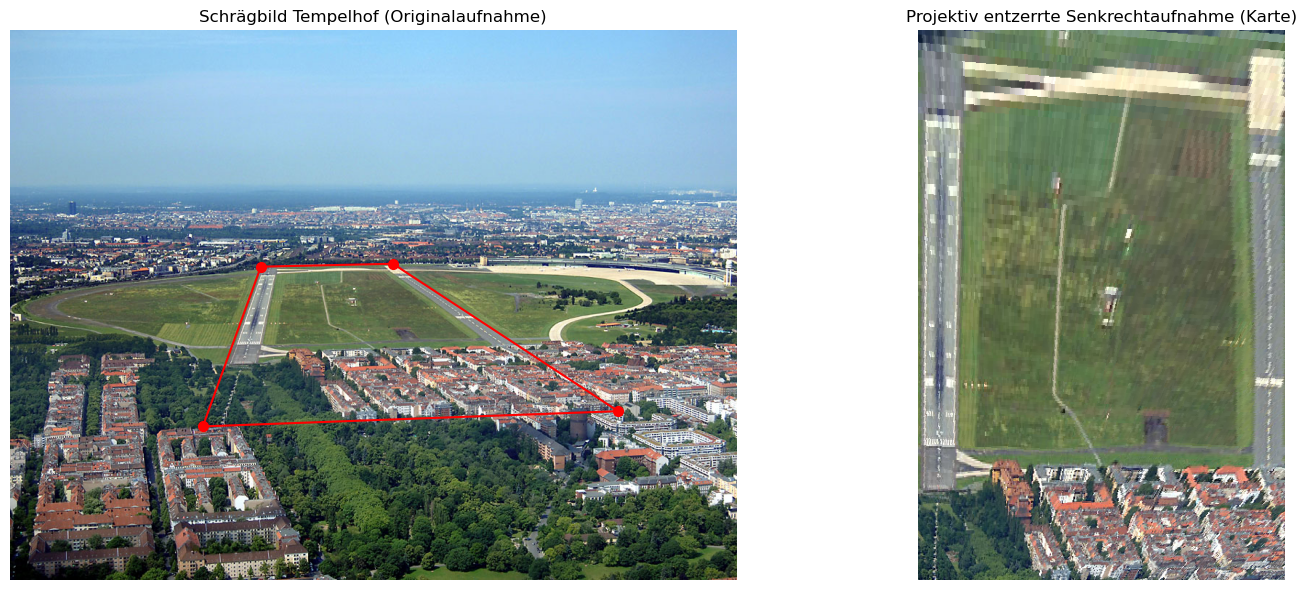

Ausgabebild: 400×600 Pixel


In [60]:
result = projective_warp(img, params, H_out, W_out)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img)
# Passpunkte einblenden
bq = b[quad_order]
axes[0].plot(bq[:, 0], bq[:, 1], 'r-', linewidth=1.5)
for i, (bx, by) in enumerate(b):
    axes[0].plot(bx, by, 'ro', markersize=7)
axes[0].set_title('Schrägbild Tempelhof (Originalaufnahme)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(result)
axes[1].set_title('Projektiv entzerrte Senkrechtaufnahme (Karte)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('entzerrung_tempelhof.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ausgabebild: {W_out}×{H_out} Pixel')